In [25]:
import numpy as np
from modules.mpo import FSM, MPO

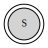

In [26]:
f = FSM()
f.draw()

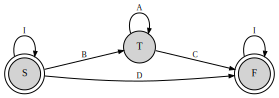

In [27]:
m = MPO()
m.default()
m.draw()

In [28]:
ising1 = MPO()

ising1.add_state(1)
ising1.add_state(2, True)

ising1.add_transition((0,0), 'I_1')
ising1.add_transition((0,1), 'X_1')
ising1.add_transition((1,2), 'X_1')
ising1.add_transition((0,2), 'Z_1')
ising1.add_transition((2,2), 'I_1')

In [29]:
ising2 = FSM()

ising2.add_state(1)
ising2.add_state(2, True)

ising2.add_transition((0,0), 'I_2')
ising2.add_transition((0,1), 'X_2')
ising2.add_transition((1,2), 'X_2')
ising2.add_transition((0,2), 'Z_2')
ising2.add_transition((2,2), 'I_2')

In [30]:
t1 = ising1.get_symbolic_table()
t2 = ising2.get_symbolic_table()

In [31]:
t1

Matrix([
[I_1, X_1, Z_1],
[  0,   0, X_1],
[  0,   0, I_1]])

In [32]:
import sympy as sp

mat = sp.Matrix([[0,0], [0,0]])

t1.subs({ising1.symbols["0"]: mat})

Matrix([
[                      I_1,                       X_1, Z_1],
[Matrix([
[0, 0],
[0, 0]]), Matrix([
[0, 0],
[0, 0]]), X_1],
[Matrix([
[0, 0],
[0, 0]]), Matrix([
[0, 0],
[0, 0]]), I_1]])

In [33]:
from sympy import Mul

expr = Mul(t1, t2, evaluate=False)
expr

Matrix([
[I_1*I_2 + X_1*0 + Z_1*0, I_1*X_2 + X_1*0 + Z_1*0, I_1*Z_2 + X_1*X_2 + Z_1*I_2],
[   0**2 + 0*I_2 + X_1*0,    0**2 + 0*X_2 + X_1*0,     0*X_2 + 0*Z_2 + X_1*I_2],
[   0**2 + 0*I_2 + I_1*0,    0**2 + 0*X_2 + I_1*0,     0*X_2 + 0*Z_2 + I_1*I_2]])

In [34]:
d = 2                            # dimension of the Hilbert space
N = np.zeros((d,d))              # empty matrix
I = np.eye(d)                    # identity matrix
X = np.array([[0.,1.],[1.,0.]])  # pauli $\sigma_x$ matrix
Y = np.array([[0.,-1j],[1j,0.]]) # pauli $\sigma_y$ matrix
Z = np.array([[1.,0.],[0.,-1.]]) # pauli $\sigma_z$ matrix

In [35]:
expr.table

<bound method MatrixBase.table of Matrix([
[I_1*I_2 + X_1*0 + Z_1*0, I_1*X_2 + X_1*0 + Z_1*0, I_1*Z_2 + X_1*X_2 + Z_1*I_2],
[   0**2 + 0*I_2 + X_1*0,    0**2 + 0*X_2 + X_1*0,     0*X_2 + 0*Z_2 + X_1*I_2],
[   0**2 + 0*I_2 + I_1*0,    0**2 + 0*X_2 + I_1*0,     0*X_2 + 0*Z_2 + I_1*I_2]])>

In [36]:
(t1*t2)

Matrix([
[I_1*I_2 + X_1*0 + Z_1*0, I_1*X_2 + X_1*0 + Z_1*0, I_1*Z_2 + X_1*X_2 + Z_1*I_2],
[   0**2 + 0*I_2 + X_1*0,    0**2 + 0*X_2 + X_1*0,     0*X_2 + 0*Z_2 + X_1*I_2],
[   0**2 + 0*I_2 + I_1*0,    0**2 + 0*X_2 + I_1*0,     0*X_2 + 0*Z_2 + I_1*I_2]])

In [37]:
t1*t2

Matrix([
[I_1*I_2 + X_1*0 + Z_1*0, I_1*X_2 + X_1*0 + Z_1*0, I_1*Z_2 + X_1*X_2 + Z_1*I_2],
[   0**2 + 0*I_2 + X_1*0,    0**2 + 0*X_2 + X_1*0,     0*X_2 + 0*Z_2 + X_1*I_2],
[   0**2 + 0*I_2 + I_1*0,    0**2 + 0*X_2 + I_1*0,     0*X_2 + 0*Z_2 + I_1*I_2]])

In [38]:
ising1.symbols

{'I_1': I_1, 'X_1': X_1, 'Z_1': Z_1, '0': 0}

In [39]:
t1.subs(ising1.symbols['I_1'], 0)


Matrix([
[0, X_1, Z_1],
[0,   0, X_1],
[0,   0,   0]])

In [40]:
import sympy as sp

d = 2                            # dimension of the Hilbert space
N = np.zeros((d,d))              # empty matrix
I = np.eye(d)                    # identity matrix
X = np.array([[0.,1.],[1.,0.]])  # pauli $\sigma_x$ matrix
Y = np.array([[0.,-1j],[1j,0.]]) # pauli $\sigma_y$ matrix
Z = np.array([[1.,0.],[0.,-1.]]) # pauli $\sigma_z$ matrix

Ns = sp.Matrix(N)
Is = sp.Matrix(I)
Xs = sp.Matrix(X)
Ys = sp.Matrix(Y)
Zs = sp.Matrix(Z)

res = t1.subs({ising1.symbols["I_1"]: Is, ising1.symbols["X_1"]: Xs, ising1.symbols["Z_1"]: Zs, ising1.symbols["0"]: Ns})
res = sp.Matrix(res).expand()
res

Matrix([
[Matrix([
[1.0,   0],
[  0, 1.0]]), Matrix([
[  0, 1.0],
[1.0,   0]]), Matrix([
[1.0,    0],
[  0, -1.0]])],
[        Matrix([
[0, 0],
[0, 0]]),         Matrix([
[0, 0],
[0, 0]]),   Matrix([
[  0, 1.0],
[1.0,   0]])],
[        Matrix([
[0, 0],
[0, 0]]),         Matrix([
[0, 0],
[0, 0]]),   Matrix([
[1.0,   0],
[  0, 1.0]])]])

In [41]:
print(t1.free_symbols)
for i in t1.free_symbols:
    print(i.shape)
print(t1.shape)
print(expr.free_symbols)
print(expr.shape)

{Z_1, I_1, 0, X_1}
(2, 2)
(2, 2)
(2, 2)
(2, 2)
(3, 3)
{Z_1, Z_2, X_2, 0, X_1, I_1, I_2}
(3, 3)


In [42]:
expr = t1 * t2
print(expr)

Matrix([[I_1*I_2 + X_1*0 + Z_1*0, I_1*X_2 + X_1*0 + Z_1*0, I_1*Z_2 + X_1*X_2 + Z_1*I_2], [0**2 + 0*I_2 + X_1*0, 0**2 + 0*X_2 + X_1*0, 0*X_2 + 0*Z_2 + X_1*I_2], [0**2 + 0*I_2 + I_1*0, 0**2 + 0*X_2 + I_1*0, 0*X_2 + 0*Z_2 + I_1*I_2]])


In [43]:
i1is = ising1.symbols["I_1"]
i1ix = ising1.symbols["X_1"]
i1iz = ising1.symbols["Z_1"]
i1in = ising1.symbols["0"]

i2is = ising2.symbols["I_2"]
i2ix = ising2.symbols["X_2"]
i2iz = ising2.symbols["Z_2"]
i2in = ising2.symbols["0"]

res = expr.subs({i1is: Is, i1ix: Xs, i1iz : Zs, i1in: Ns,
                 i2is: Is, i2ix: Xs, i2iz : Zs, i2in: Ns})

res

Matrix([
[Matrix([
[  0, 1.0],
[1.0,   0]])*Matrix([
[0, 0],
[0, 0]]) + Matrix([
[1.0,    0],
[  0, -1.0]])*Matrix([
[0, 0],
[0, 0]]) + Matrix([
[1.0,   0],
[  0, 1.0]])*Matrix([
[1.0,   0],
[  0, 1.0]]), Matrix([
[  0, 1.0],
[1.0,   0]])*Matrix([
[0, 0],
[0, 0]]) + Matrix([
[1.0,    0],
[  0, -1.0]])*Matrix([
[0, 0],
[0, 0]]) + Matrix([
[1.0,   0],
[  0, 1.0]])*Matrix([
[  0, 1.0],
[1.0,   0]]), Matrix([
[  0, 1.0],
[1.0,   0]])*Matrix([
[  0, 1.0],
[1.0,   0]]) + Matrix([
[1.0,    0],
[  0, -1.0]])*Matrix([
[1.0,   0],
[  0, 1.0]]) + Matrix([
[1.0,   0],
[  0, 1.0]])*Matrix([
[1.0,    0],
[  0, -1.0]])],
[                                         Matrix([
[0, 0],
[0, 0]])*Matrix([
[1.0,   0],
[  0, 1.0]]) + Matrix([
[  0, 1.0],
[1.0,   0]])*Matrix([
[0, 0],
[0, 0]]) + Matrix([
[0, 0],
[0, 0]])**2,                                          Matrix([
[0, 0],
[0, 0]])*Matrix([
[  0, 1.0],
[1.0,   0]]) + Matrix([
[  0, 1.0],
[1.0,   0]])*Matrix([
[0, 0],
[0, 0]]) + Matrix([
[0, 0],
[0, 0]])

In [44]:
res[0]

Matrix([
[  0, 1.0],
[1.0,   0]])*Matrix([
[0, 0],
[0, 0]]) + Matrix([
[1.0,    0],
[  0, -1.0]])*Matrix([
[0, 0],
[0, 0]]) + Matrix([
[1.0,   0],
[  0, 1.0]])*Matrix([
[1.0,   0],
[  0, 1.0]])

In [45]:
explicits = {} 
for i, e in enumerate(res):
    explicits[i] = e.as_explicit()

for i in explicits:
    res[i] = explicits[i]

ShapeError: 
The Matrix `value` doesn't have the same dimensions as the in sub-
Matrix given by `key`.

In [24]:
res

Matrix([
[0, 1, 2],
[3, 4, 5],
[6, 7, 8]])

In [ ]:
from sympy import MatrixSymbol, Matrix

x1 = MatrixSymbol('x1', 2, 2)
x2 = MatrixSymbol('x2', 2, 2)
expr = (x1*x2**2)
expr

In [ ]:
x1_sub = Matrix([[0,1],[1,0]])
x2_sub = Matrix([[1,0],[0,1]])

expr.subs({x1: x1_sub, x2: x2_sub}).as_explicit()